# Practical Exam Python for Scientists 2026-01-15

**Start of the exam:** Thu, January 15th, 2026, 2:00 PM.

**Submission deadline:** Thu, January 15th, 2026, 5:00 PM.

**Course of the exam:**
The practical exam consists of two parts: a coding part and a written part. This notebook is the coding part. After you submitted the coding part and put away your laptop, you will receive some questions on paper, which are all related to the coding exercise.

**Allowed during the coding part:**

- You can use any material from the course.
- You can consult online resources.
- If you have a question about one of the questions below, ask Jorden De Bolle, Toon Verstraelen or Jonathan Leliaert.

**Not allowed during the coding part:**

- Do not communicate with anyone (except with the lecturers).
- Do not collaborate with anyone.
- Do not ask anyone to check your solutions.
- Do not use any shared accounts (such as for chatGPT)

**Allowed during the written part:**

- If you have a question about one of the questions, ask Jorden De Bolle, Toon Verstraelen or Jonathan Leliaert.

**Not allowed during the written part:**

- Do not use any course materials. The written part is a closed book exam.
- Do not communicate with anyone (except with the lecturers).
- Do not collaborate with anyone.
- Do not ask anyone to check your solutions.
- Do not use your laptop and do not consult online resources

**During the coding part, you are expected to:**

- Solve all the problems below by implementing the solution in Python.
- Make sure the notebook works as expected and shows all results when you restart it from scratch:
  - In the Jupyter Notebook Classic menu `Kernel` > `Restart & Run All`.
  - In the new Jupyter Lab or Notebook menu `Kernel` > `Restart Kernel and Run All Cells...`.
- The notebook must execute until the end without user intervention,
  so do not use `input` or other interactive functions.
- Before the deadline, you must upload to Ufora the **modified version of this notebook** with your solutions,
  not a notebook with answers only nor the original one without answers.

**During the written part, you are expected to:**
- Answer all questions, concise and to the point. Excessively long answers will lower your mark.

**You are NOT expected to:**

- Write unit tests.
- Write docstrings.

**The main evaluation criteria are:**

1. correctness of the implementations,
2. appropriate choice of the algorithm to solve each problem,
3. clarity of the source code (meaningful choice of variable names, compactness of the answer, only including the code that must be present), and
4. quality of the figures as discussed in the matplotlib demo,
5. correctness of the answers on the questions on the written part of the exam.

**The practical exam counts for 8 of the 20 points of this course: 5 points for the coding part, 3 points for the written part.**

You will need the following imports:

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Exercise: Orbital dynamics

A satellite of $10800\,\mathrm{kg}$ is orbiting the earth and needs to move to a new, larger, orbit. 
Your goal is to find the right time to ignite the engine and how long the engine must keep burning in order to reach the desired orbit.
You will do this step by step, by integrating an orbit based on Newton's equations of motion, fitting an ellipse to the orbit and optimising the ignition time and engine cut-off time.
Because gravitational orbits always take place in one plane, you can work in 2D.

Below you find some useful constants, expressed in units that are most convenient for this exercise.

In [2]:
# time unit = 1 hour
# distance unit = 1 km
MASS_EARTH = 5.972e24  # kg
GRAV_CONST = 8.650e-13  # km^3 kg^-1 hour^-2.
MASS_SAT = 1.08e4  # kg
GM = MASS_EARTH * GRAV_CONST

## Part 1: basic simulation of orbital dynamics (2.5 points)

### 1.1 Determine initial conditions

Determine initial conditions (2D position vector and 2D velocity vector) for the spacecraft's initial orbit based on the following facts:

- Assume circular motion
- The period is $T = 1.583\,\mathrm{h}$
- The starting position is on the positive x-axis
- The movement is counterclockwise

In [3]:
# Initial conditions for circular orbit
T = 1.583  # hours
# Kepler's 3rd law we saw in the course sterren & planeten and (theoretische) mechanica.
r0 = (GM * (T / (2 * np.pi)) ** 2) ** (1 / 3)  # km 

# boundary conditions
pos0 = np.array([r0, 0.0]) # (x=r0, y=0)
v_mag = 2 * np.pi * r0 / T  # km/hour (tangential speed)
vel0 = np.array([0.0, v_mag])  # counterclockwise, start on +x
pos0, vel0

(array([6895.71546657,    0.        ]),
 array([    0.        , 27370.21990024]))

### 1.2 Integration of the orbit

Write a function that integrates the orbit using Newton's equations of motion. 
Include the possibility of igniting the engine of the spacecraft at a given time `t_start` until a later time `t_stop`. 
You may assume the engine always exerts a force of $10^4\,\mathrm{N}$ and the thrust is always in the direction of motion.

**Hint: don't forget to correctly convert the unit of force.**

In [4]:
# Orbit integrator with optional thrust
THRUST_N = 1e4  # Newton

# Convert thrust to km/hour^2 per unit mass
a_thrust_kmh2 = (THRUST_N / MASS_SAT) * 1e-3 * (3600 ** 2)

def integrate_orbit(t_end, t_start=0.0, t_stop=0.0, n_steps=2000):
    """Integrate orbit with optional thrust between t_start and t_stop."""
    def rhs(t, state):
        pos, vel = state[:2], state[2:]
        r = np.linalg.norm(pos)
        grav = -GM * pos / (r ** 3)
        thrust = np.zeros(2)
        speed = np.linalg.norm(vel)
        if t_start <= t <= t_stop and speed > 0:
            thrust = a_thrust_kmh2 * vel / speed
        return np.hstack((vel, grav + thrust))

    y0 = np.hstack((pos0, vel0))
    t_eval = np.linspace(0.0, t_end, n_steps)
    sol = scipy.integrate.solve_ivp(rhs, (0.0, t_end), y0, t_eval=t_eval, rtol=1e-9, atol=1e-12)
    return sol.t, sol.y.T


### 1.3 Plot the orbit (with earth)

Integrate the orbit of the spacecraft for 10 hours, where the egine is ignited at $t_{start} = 1.9 \times T$ and shut down at $t_{stop} = 2.0 \times T$ with $T=1.583\mathrm{h}$. Plot the found orbit. Don't forget to add the earth to your figure (for example as a blue circle with a radius of 6371 km).

array([-8069.49396545,  4344.25604719])

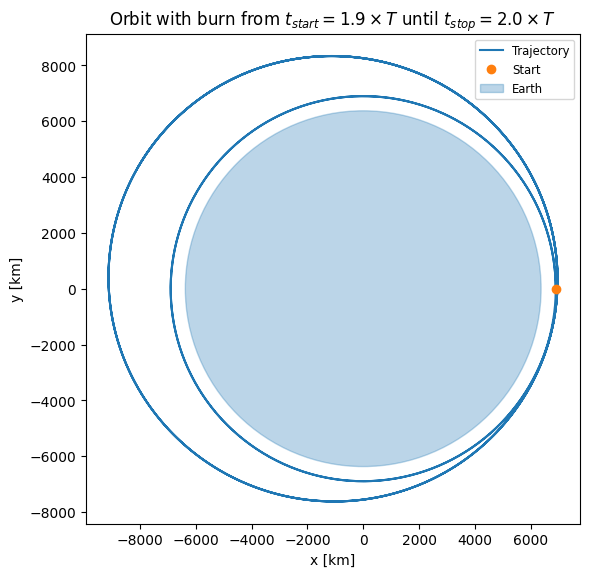

In [5]:
# Integrate 10 hours with burn between 1.9T and 2.0T, then plot with earth
plt.close("orbit_with_burn")
fig, ax = plt.subplots(num="orbit_with_burn", figsize=(6, 6))

burn_start = 1.9 * T
burn_stop = 2.0 * T
sim_hours = 10.0

_, trajectory = integrate_orbit(t_end=sim_hours, t_start=burn_start, t_stop=burn_stop, n_steps=3000)
positions = trajectory[:, :2]

ax.plot(positions[:, 0], positions[:, 1], label="Trajectory")
ax.plot(positions[0, 0], positions[0, 1], "o", color="C1", label="Start")
ax.add_patch(patches.Circle((0.0, 0.0), 6371, color="C0", alpha=0.3, label="Earth"))
ax.set_aspect("equal", "box")
ax.set_xlabel("x [km]")
ax.set_ylabel("y [km]")
ax.legend(loc="upper right", fontsize="small") # small size to not overlap the figure.
ax.set_title(r"Orbit with burn from $t_{start} = 1.9 \times T$ until $t_{stop} = 2.0 \times T$")
fig.tight_layout()

positions[-1]

## Part 2: Fitting an ellipse to the orbit (1 point)
A closed orbit of a spacecraft is always an ellipse. Use linear least squares to fit an ellipse to the final orbit (after the engine was shut down) you plotted above and calculate long axis, short axis and rotation angle w.r.t. the x-axis. Some useful equations are given below.

Make a clear plot of the orbit and the fitted ellipse together.

| Quantity | Expression |
|----------|------------|
| Ellipse equation | $x^2 = A y^2 + B x y + C x + D y + E$ |
| Center ($x$-coordinate) | $x_0 = \dfrac{2 A C - B D}{B^2 + 4 A}$ |
| Center ($y$-coordinate) | $y_0 = \dfrac{-2 D - B C}{B^2 + 4 A}$ |
| Rotation angle | $\theta = \dfrac{1}{2}\arctan\!\left(\dfrac{B}{-1 - A}\right)$ |
| Eigenvalues | $\lambda_{1,2} = \dfrac{1 - A \pm \sqrt{(-1 - A)^2 + B^2}}{2}$ |
| Constant term | $F = E + C x_0 + D y_0 - x_0^2 + B x_0 y_0 + A y_0^2$ |
| Semi-major axis | $a = \sqrt{\dfrac{F}{\min(\lambda_1,\lambda_2)}}$ |
| Semi-minor axis | $b = \sqrt{\dfrac{F}{\max(\lambda_1,\lambda_2)}}$ |


Center: (-1081.41, 356.04) km
Rotation theta: -18.22 deg
Semi-major a: 8049.33 km, Semi-minor b: 7968.40 km


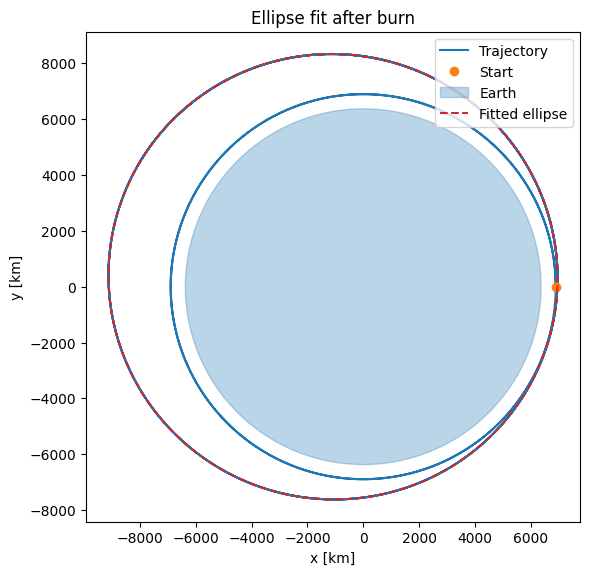

In [6]:
# Fit ellipse to the post-burn orbit and plot
plt.close("orbit_ellipse_fit")
fig, ax = plt.subplots(num="orbit_ellipse_fit", figsize=(6, 6))

burn_start, burn_stop, sim_hours = 1.9 * T, 2.0 * T, 10.0

times, trajectory = integrate_orbit(t_end=sim_hours, t_start=burn_start, t_stop=burn_stop, n_steps=3000)
positions = trajectory[:, :2]

def fit_ellipse(x, y):
    """Fit ellipse to (x, y) data using linear least squares. Returns (a, b, theta_deg, x0, y0)."""
    M = np.column_stack((y**2, x * y, x, y, np.ones_like(x)))
    A, B, C, D, E = np.linalg.lstsq(M, x**2, rcond=None)[0]
    x0 = (2 * A * C - B * D) / (B**2 + 4 * A)
    y0 = (-2 * D - B * C) / (B**2 + 4 * A)
    theta = 0.5 * np.arctan(B / (-1 - A))
    lambda1 = (1 - A + np.sqrt((-1 - A) ** 2 + B**2)) / 2
    lambda2 = (1 - A - np.sqrt((-1 - A) ** 2 + B**2)) / 2
    F = E + C * x0 + D * y0 - x0**2 + B * x0 * y0 + A * y0**2
    denom_a, denom_b = min(lambda1, lambda2), max(lambda1, lambda2)
    if F / denom_a <= 0 or F / denom_b <= 0:
        return np.inf, np.inf, 0.0, x0, y0
    return np.sqrt(F / denom_a), np.sqrt(F / denom_b), np.degrees(theta), x0, y0


# Fit ellipse to post-burn data only
x, y = positions[times >= burn_stop, 0], positions[times >= burn_stop, 1]
a, b, theta_deg, x0, y0 = fit_ellipse(x, y)

# Plot trajectory and Earth
ax.plot(positions[:, 0], positions[:, 1], label="Trajectory")
ax.plot(positions[0, 0], positions[0, 1], "o", color="C1", label="Start")
ax.add_patch(patches.Circle((0.0, 0.0), 6371, color="C0", alpha=0.3, label="Earth"))

# Plot fitted ellipse (parametric form)
phi = np.linspace(0, 2 * np.pi, 400)
cos_t, sin_t = np.cos(np.radians(theta_deg)), np.sin(np.radians(theta_deg))
ellipse_x = x0 + a * np.cos(phi) * cos_t - b * np.sin(phi) * sin_t
ellipse_y = y0 + a * np.cos(phi) * sin_t + b * np.sin(phi) * cos_t
ax.plot(ellipse_x, ellipse_y, "--", color="C3", label="Fitted ellipse")

ax.set_aspect("equal", "box")
ax.set_xlabel("x [km]")
ax.set_ylabel("y [km]")
ax.legend(loc="upper right")
ax.set_title("Ellipse fit after burn")
fig.tight_layout()

print(f"Center: ({x0:.2f}, {y0:.2f}) km")
print(f"Rotation theta: {theta_deg:.2f} deg")
print(f"Semi-major a: {a:.2f} km, Semi-minor b: {b:.2f} km")

## Part 3: Finding parameters to reach a desired orbit (1.5 points)

Start again from the original orbit, for which you determined starting conditions in Part 1.1. Use a minimization procedure to find $t_\text{start}$ and $t_\text{stop}$ for engine ignition and shut down respectively, such that an orbit is obtained with target values $a = 10264\,\mathrm{km}$, $b = 9748\,\mathrm{km}$, $\theta = 20.81^\circ$.

- Make sure the spacecraft completed at least two full orbits before transitioning to the new orbit.
- Make sure the motor is not activated for longer half the period of the original orbit
- Make sure $t_\text{start} < t_\text{stop}$.
- Use $(a-a_\text{target})^2 + (b-b_\text{target})^2 + (100(\theta-\theta_\text{target}))^2$ as cost function
- Use the COBYQA method in your minimization procedure

Integrate the orbit using the values you found for $t_\text{start}$ and $t_\text{stop}$, fit an ellipse to the final orbit and print out the values you obtain for $a$, $b$ and $\theta$. Plot the integrated orbit and the fit.

⚠️ The minimization might take a few minutes to complete (not more than 5). The found values for $a$, $b$ and $\theta$ should be within 25 km and 1° from the desired values. ⚠️ 

Optimized t_start=3.482 hours, t_stop=3.837 hours
Target: a=10264.00 km, b=9748.00 km, theta=20.81°
Fit:    a=10263.91 km, b=9748.13 km, theta=20.81°
Errors: Δa=9.08e-02 km, Δb=1.28e-01 km, Δθ=1.17e-05°


(np.float64(3.4822935075537345),
 np.float64(3.836796995153502),
 np.float64(10263.909152228405),
 np.float64(9748.128031601751),
 np.float64(20.810011669088993))

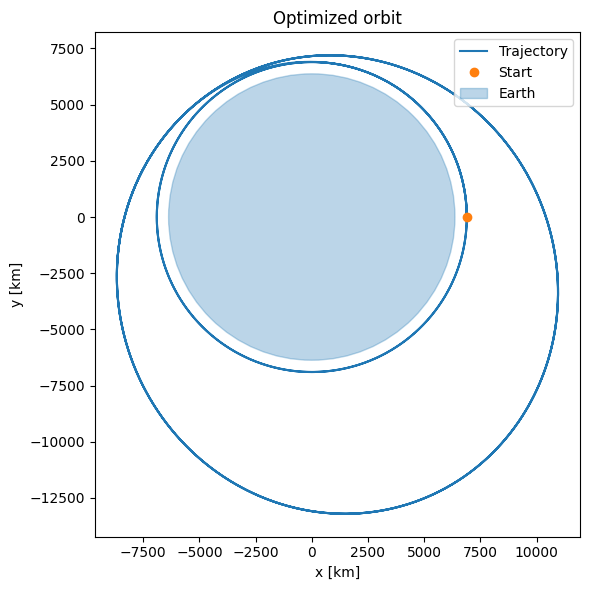

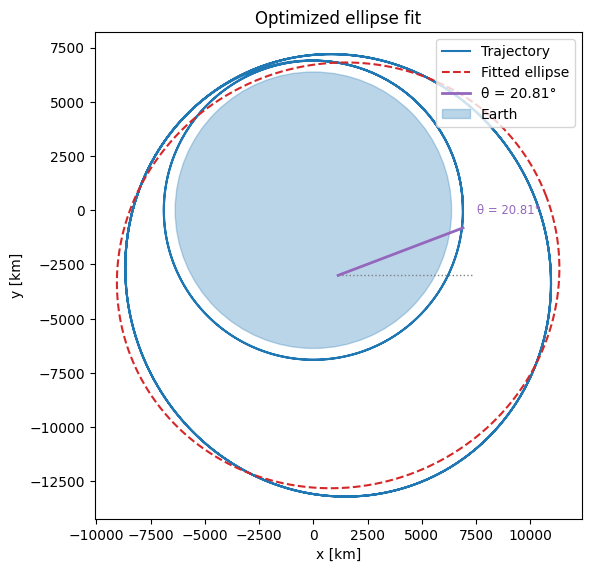

In [7]:
# Optimize t_start and t_stop to hit target ellipse using COBYQA
plt.close("optimized_orbit")
plt.close("optimized_orbit_fit")

a_target, b_target, theta_target_deg = 10264.0, 9748.0, 20.81  # target ellipse [km, km, deg]
sim_hours = 8.0 * T

# Objective: squared error between fitted and target ellipse
def objective(vars):
    t_start, t_stop = vars
    times, traj = integrate_orbit(t_end=sim_hours, t_start=t_start, t_stop=t_stop, n_steps=4000)
    x, y = traj[times >= t_stop, 0], traj[times >= t_stop, 1]
    a, b, theta_deg, _, _ = fit_ellipse(x, y)
    return (a - a_target)**2 + (b - b_target)**2 + (100 * (theta_deg - theta_target_deg))**2

# Constraints for COBYQA
constraints = [
    {"type": "ineq", "fun": lambda v: v[0] - 2 * T},              # t_start >= 2T
    {"type": "ineq", "fun": lambda v: 0.5 * T - (v[1] - v[0])},   # duration <= 0.5T
    {"type": "ineq", "fun": lambda v: v[1] - v[0] - 1e-3},        # t_stop > t_start
    {"type": "ineq", "fun": lambda v: sim_hours - v[1] - 1e-3},   # burn ends before simulation ends
]

result = scipy.optimize.minimize(objective, [2.1 * T, 2.4 * T], method="COBYQA", 
                                  constraints=constraints, options={"maxiter": 200})
opt_t_start, opt_t_stop = result.x
print(f"Optimized t_start={opt_t_start:.3f} hours, t_stop={opt_t_stop:.3f} hours")

# ---- Final integration and ellipse fit with optimal parameters ----
times, traj = integrate_orbit(t_end=sim_hours, t_start=opt_t_start, t_stop=opt_t_stop, n_steps=4000)
positions = traj[:, :2]
x, y = positions[times >= opt_t_stop, 0], positions[times >= opt_t_stop, 1]
a_fit, b_fit, theta_fit_deg, x0_fit, y0_fit = fit_ellipse(x, y)

print(f"Target: a={a_target:.2f} km, b={b_target:.2f} km, theta={theta_target_deg:.2f}°")
print(f"Fit:    a={a_fit:.2f} km, b={b_fit:.2f} km, theta={theta_fit_deg:.2f}°")
print(f"Errors: Δa={abs(a_fit-a_target):.2e} km, Δb={abs(b_fit-b_target):.2e} km, Δθ={abs(theta_fit_deg-theta_target_deg):.2e}°")

# ---- Plot 1: Optimized orbit trajectory ----
fig, ax = plt.subplots(num="optimized_orbit", figsize=(6, 6))
ax.plot(positions[:, 0], positions[:, 1], label="Trajectory")
ax.plot(positions[0, 0], positions[0, 1], "o", color="C1", label="Start")
ax.add_patch(patches.Circle((0.0, 0.0), 6371, color="C0", alpha=0.3, label="Earth"))
ax.set_aspect("equal", "box")
ax.set_xlabel("x [km]")
ax.set_ylabel("y [km]")
ax.legend(loc="upper right")
ax.set_title("Optimized orbit")
fig.tight_layout()

# ---- Plot 2: Orbit with fitted ellipse overlay ----
fig2, ax2 = plt.subplots(num="optimized_orbit_fit", figsize=(6, 6))
phi = np.linspace(0, 2 * np.pi, 400)
cos_t, sin_t = np.cos(np.radians(theta_fit_deg)), np.sin(np.radians(theta_fit_deg))
ellipse_x = x0_fit + a_fit * np.cos(phi) * cos_t - b_fit * np.sin(phi) * sin_t
ellipse_y = y0_fit + a_fit * np.cos(phi) * sin_t + b_fit * np.sin(phi) * cos_t
ax2.plot(positions[:, 0], positions[:, 1], label="Trajectory")
ax2.plot(ellipse_x, ellipse_y, "--", color="C3", label="Fitted ellipse")
angle_len = max(a_fit, b_fit) * 0.6
ax2.plot([x0_fit, x0_fit + angle_len], [y0_fit, y0_fit], color="gray", lw=1, ls=":")
ax2.plot([x0_fit, x0_fit + angle_len * cos_t], [y0_fit, y0_fit + angle_len * sin_t], color="C4", lw=2, label=f"θ = {theta_fit_deg:.2f}°")
ax2.annotate(f"θ = {theta_fit_deg:.2f}°", xy=(x0_fit + angle_len * cos_t, y0_fit + angle_len * sin_t),
             xytext=(10, 10), textcoords="offset points", color="C4", fontsize="small")
ax2.add_patch(patches.Circle((0.0, 0.0), 6371, color="C0", alpha=0.3, label="Earth"))
ax2.set_aspect("equal", "box")
ax2.set_xlabel("x [km]")
ax2.set_ylabel("y [km]")
ax2.legend(loc="upper right")
ax2.set_title("Optimized ellipse fit")
fig2.tight_layout()

(opt_t_start, opt_t_stop, a_fit, b_fit, theta_fit_deg)

Note:

The fitted ellipse (in red) is the **ideal ellipse**, and the blue trajectory is the **true trajectory** of the satellite. 